In [1]:
%load_ext autoreload
%autoreload 2

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))


In [2]:
from gecco import GeCCoConfig, GeCCoPipeline
from gecco.preprocess import DataPreprocessor
from gecco.tree import ModuleTreeBuilder, ModuleNode
from gecco.visualize import plot_module_tree, plot_node_genes

In [3]:
adata = sc.read_h5ad('../datasets/adata_ngn3_ss.h5ad')


In [4]:
cfg = GeCCoConfig()
cfg.pp_n_depth2 = 0 
cfg.pp_enabled = True
preprocessor = DataPreprocessor(cfg)
pre = preprocessor.run(adata)

In [5]:
pipeline = GeCCoPipeline(cfg)
result = pipeline.run(adata, pre)

图已保存至: ../outputs/module_tree_ngn3.png


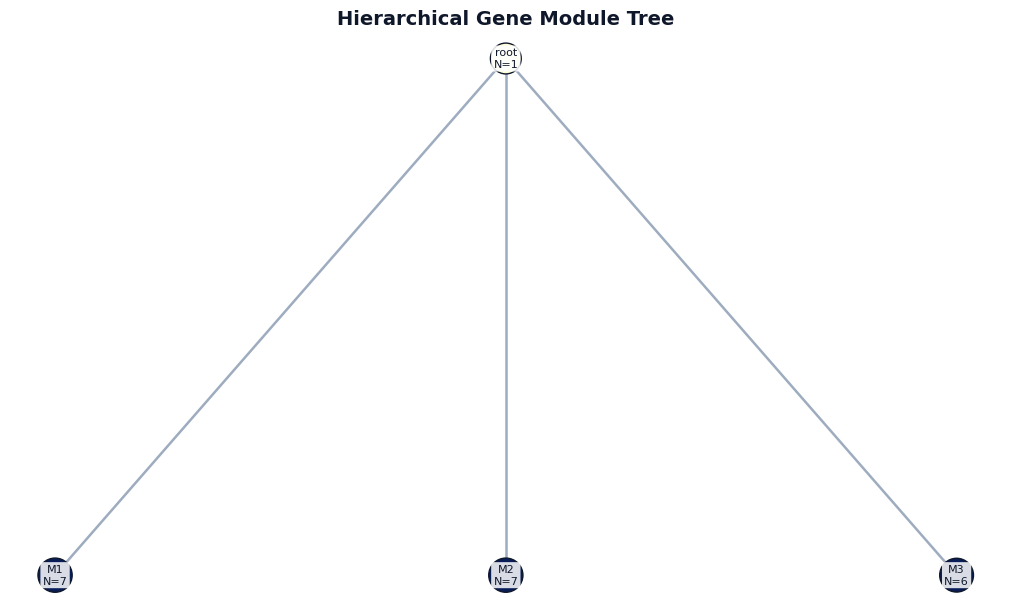

In [6]:
plot_module_tree(result.tree_root, "../outputs/module_tree_ngn3.png")

图已保存至: ../outputs/node_genes.png


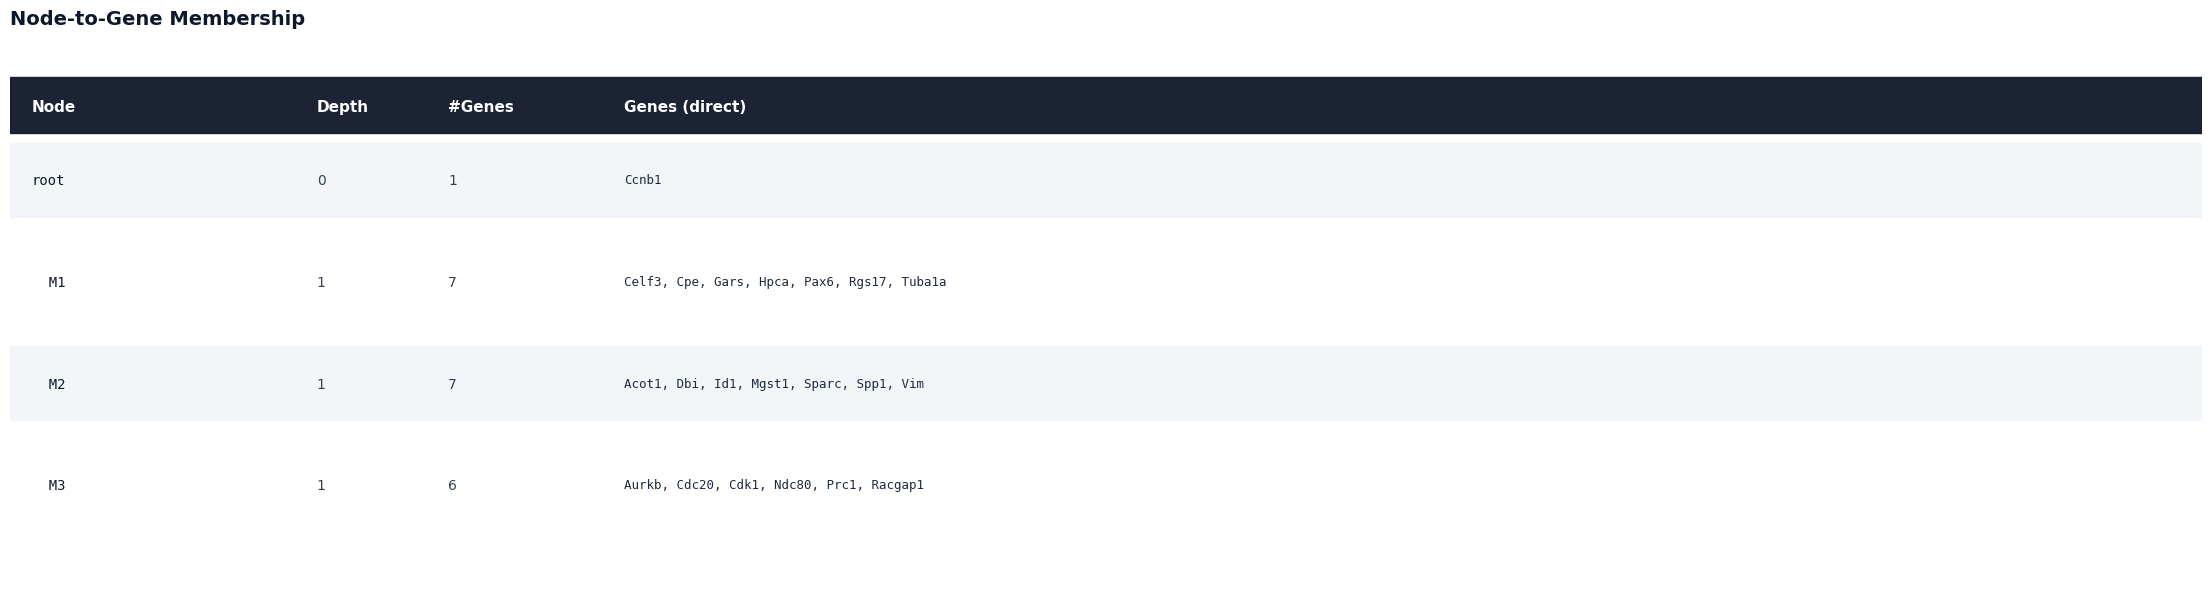

In [8]:
plot_node_genes(result.tree_root,"../outputs/node_genes.png")

In [10]:
from gecco.utils import add_tree_labels_to_var
add_tree_labels_to_var(adata, result.tree_root)

In [14]:
m1_genes = adata.var[adata.var['depth1'] == 'M1'].index.tolist()
m2_genes = adata.var[adata.var['depth1'] == 'M3'].index.tolist()
m3_genes = adata.var[adata.var['depth1'] == 'M2'].index.tolist()

total_genes = m1_genes + m2_genes + m3_genes

gene_to_idx = {g: i for i, g in enumerate(pre.gene_names)}
gene_indices = [gene_to_idx[g] for g in total_genes if g in gene_to_idx]
total_genes_ordered = [g for g in total_genes if g in gene_to_idx]

phi_sub = pre.phi[np.ix_(gene_indices, gene_indices)]
np.fill_diagonal(phi_sub, 1) 

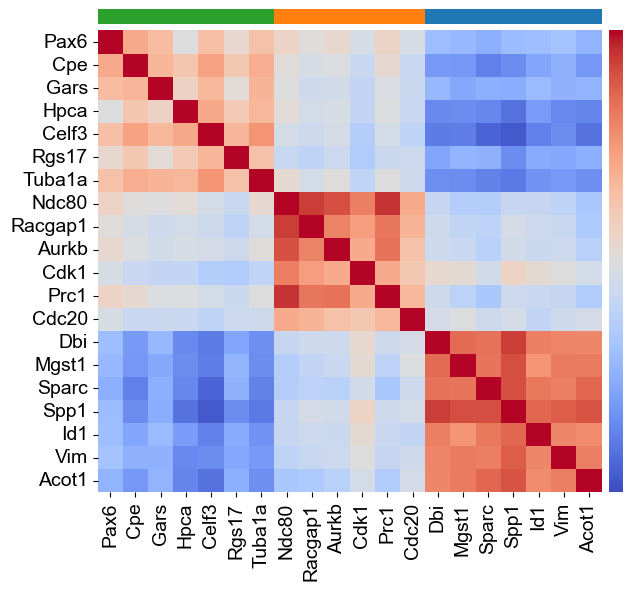

In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

module_colors = {'M1': '#2ba02d', 'M2': '#fe7f0e', 'M3': '#1f78b4'}

module_labels = (
    ['M1'] * len([g for g in m1_genes if g in gene_to_idx]) +
    ['M2'] * len([g for g in m2_genes if g in gene_to_idx]) +
    ['M3'] * len([g for g in m3_genes if g in gene_to_idx])
)
bar_colors = [module_colors[m] for m in module_labels]

n = len(total_genes_ordered)

plt.rcParams['font.family'] = 'Arial'

fig = plt.figure(figsize=(7, 6))

ax_bar  = fig.add_axes([0.12, 0.88, 0.72, 0.025])
ax_heat = fig.add_axes([0.12, 0.10, 0.72, 0.77])
ax_cbar = fig.add_axes([0.85, 0.10, 0.02, 0.77])

# ── Top color strip ──────────────────────────────────────────────────────────
for i, c in enumerate(bar_colors):
    ax_bar.add_patch(mpatches.Rectangle((i, 0), 1, 1, color=c, linewidth=0))
ax_bar.set_xlim(0, n)
ax_bar.set_ylim(0, 1)
ax_bar.axis('off')

# ── Heatmap ──────────────────────────────────────────────────────────────────
sns.heatmap(
    phi_sub,
    ax=ax_heat,
    cmap='coolwarm',
    vmin=-0.57, vmax=0.72,
    xticklabels=total_genes_ordered,
    yticklabels=total_genes_ordered,
    cbar_ax=ax_cbar,
    linewidths=0,
)

# tick labels: Arial, no italic, larger font
ax_heat.set_xticklabels(ax_heat.get_xticklabels(), fontsize=14, fontstyle='normal', rotation=90)
ax_heat.set_yticklabels(ax_heat.get_yticklabels(), fontsize=14, fontstyle='normal', rotation=0)

# colorbar: no ticks
ax_cbar.set_yticks([])
ax_cbar.set_xticks([])

plt.savefig('../outputs/phi_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()